# Trial-wise decoded neural measures from the production decoding

Extracts the trial-wise posterior mean (E) and posterior SD from the production decoding (model 31, smoothed, spherical noise, n_voxels=0), joins them to the behavioral data, and runs median-split rm-ANOVAs (high vs. low decoded E / decoded SD) on the response errors.

Writes `derivatives/decoding2/decoding_pars.tsv` (trial-wise E, SD, behavior, median splits) and `derivatives/decoding2/decoding_pdf.tsv` (full posterior PDFs), which are consumed by the Stan fMRI model variants and `behavior_vs_fmri.ipynb`.

**Caution:** `get_pdf()` re-attaches the trial index by assigning `paradigm.index` positionally, assuming the pre-2026-03-05 `decode.py` output convention. Newer decoding TSVs carry a 5-level index; verify trial alignment before re-running on those outputs.

In [3]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids, get_all_behavioral_data
from neural_priors.encoding_model.decode import get_decoding_paradigm
import numpy as np
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = Path('/data/ds-neuralpriors')

model_label = 31
spherical_noise = True


def get_pdf(subject, smoothed=False, model_label=4, fit_responses=False, n_voxels=100, spherical_noise=False):
    # Load subject
    sub = Subject(subject, bids_folder=bids_folder)

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_responses:
        key += '.fit_responses'

    target_dir = bids_folder / 'derivatives' / 'decoding2' / key / f'sub-{subject}' / 'func'

    # sub-04_mask-NPCr_nvoxels-100_pars.tsv
    pdf = pd.read_csv(target_dir / f'sub-{subject}_mask-NPCr_nvoxels-{n_voxels}_pars.tsv', sep='\t', index_col=[0,1], header=[0,1], )
    paradigm = get_decoding_paradigm(sub, fit_responses=fit_responses, drop_levels=False)
    pdf.index = paradigm.index

    pdf.set_index(paradigm['x'], append=True, inplace=True)
    pdf.set_index(paradigm['range'], append=True, inplace=True)

    pdf.columns.names = ['n', 'range']

    # Make first level of columns float 32
    new_columns = pd.MultiIndex.from_arrays([pdf.columns.get_level_values(0).astype(np.float32), pdf.columns.get_level_values(1)], names=pdf.columns.names)

    # Assign the new MultiIndex back to the DataFrame
    pdf.columns = new_columns

    return pdf

def summarize_pdf(pdf):
    pdf0 = pdf.xs('0.0', level=1, axis=1)
    
    pdf0 /= np.trapz(pdf0, pdf0.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E0 = np.trapz(pdf0 * pdf0.columns.values.astype(float)[np.newaxis, :], pdf0.columns.astype(np.float32), axis=1)

    sd0 = np.trapz(np.abs(E0[:, np.newaxis] - pdf0.columns.values.astype(float)[np.newaxis, :]) * pdf0, pdf0.columns.astype(np.float32), axis=1)

    pdf1 = pdf.xs('1.0', level=1, axis=1)
    pdf1 /= np.trapz(pdf1, pdf1.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E1 = np.trapz(pdf1 * pdf1.columns.values.astype(float)[np.newaxis, :], pdf1.columns.astype(np.float32), axis=1)
    sd1 = np.trapz(np.abs(E1[:, np.newaxis] - pdf1.columns.values.astype(float)[np.newaxis, :]) * pdf1, pdf1.columns.astype(np.float32), axis=1)

    ix_ = pd.IndexSlice

    pdf0_ = pdf0.loc[:, :25]
    pdf0_ /= np.trapz(pdf0_, pdf0_.columns.astype(np.float32), axis=1)[:, np.newaxis]

    E = np.where(pdf.index.get_level_values('range') == 0.0, E0, E1)
    sd = np.where(pdf.index.get_level_values('range') == 0.0, sd0, sd1)

    pars = pd.DataFrame(index=pdf.index, columns=['E', 'sd'])
    pars['E'] = E
    pars['sd'] = sd

    pars.reset_index(['x', 'range'], inplace=True)

    pars['error'] = pars['E'] - pars['x']
    pars['abs(error)'] = np.abs(pars['error'])

    return pars

In [4]:
subjects = get_all_subject_ids()

fit_responses = False
n_voxels = 0
spherical_noise = True
model_label = 31

pdfs = []
keys = []
pars = []

for subject, smoothed in product(subjects, [True, False]): 
    try:
        pdf = get_pdf(subject, smoothed=smoothed, model_label=model_label, fit_responses=fit_responses, n_voxels=n_voxels, spherical_noise=spherical_noise)
        pars_ = summarize_pdf(pdf)
        pdfs.append(pdf)
        keys.append((subject, smoothed))
        pars.append(pars_.droplevel('subject'))
    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit_responses={fit_responses}, n_voxels={n_voxels}: {e}')
        continue
    except Exception as e:
        print(f'Error for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit: {e}, {fit_responses}, (n_voxels={n_voxels})')
        continue

pdf = pd.concat(pdfs, keys=keys, names=['subject', 'smoothed'])
pars = pd.concat(pars, keys=keys, names=['subject', 'smoothed'])

  0%|          | 0/78 [00:00<?, ?it/s]

File not found for subject 01, smoothed=False, model_label=31, fit_responses=False, n_voxels=0: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/decoding2/model31.spherical_noise/sub-01/func/sub-01_mask-NPCr_nvoxels-0_pars.tsv'
File not found for subject 02, smoothed=False, model_label=31, fit_responses=False, n_voxels=0: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/decoding2/model31.spherical_noise/sub-02/func/sub-02_mask-NPCr_nvoxels-0_pars.tsv'
File not found for subject 03, smoothed=False, model_label=31, fit_responses=False, n_voxels=0: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/decoding2/model31.spherical_noise/sub-03/func/sub-03_mask-NPCr_nvoxels-0_pars.tsv'
File not found for subject 04, smoothed=False, model_label=31, fit_responses=False, n_voxels=0: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/decoding2/model31.spherical_noise/sub-04/func/sub-04_mask-NPCr_nvoxels-0_pars.t

In [ ]:
df = get_all_behavioral_data(bids_folder, )
df = df.join(pars[['E', 'sd',]].droplevel('run2'))
df['E_median_split'] = (
    df.groupby(['subject', 'n', 'range'])['E']
    .transform(lambda x: (x > x.median()).map({True: 'high', False: 'low'}))
)

df['sd_median_split'] = (
    df.groupby(['subject', 'n', 'range'])['sd']
    .transform(lambda x: (x > x.median()).map({True: 'high', False: 'low'}))
)


In [85]:
df.to_csv(bids_folder / 'derivatives' / 'decoding2' / 'decoding_pars.tsv', sep='\t')
pdf.to_csv(bids_folder / 'derivatives' / 'decoding2' / 'decoding_pdf.tsv', sep='\t')

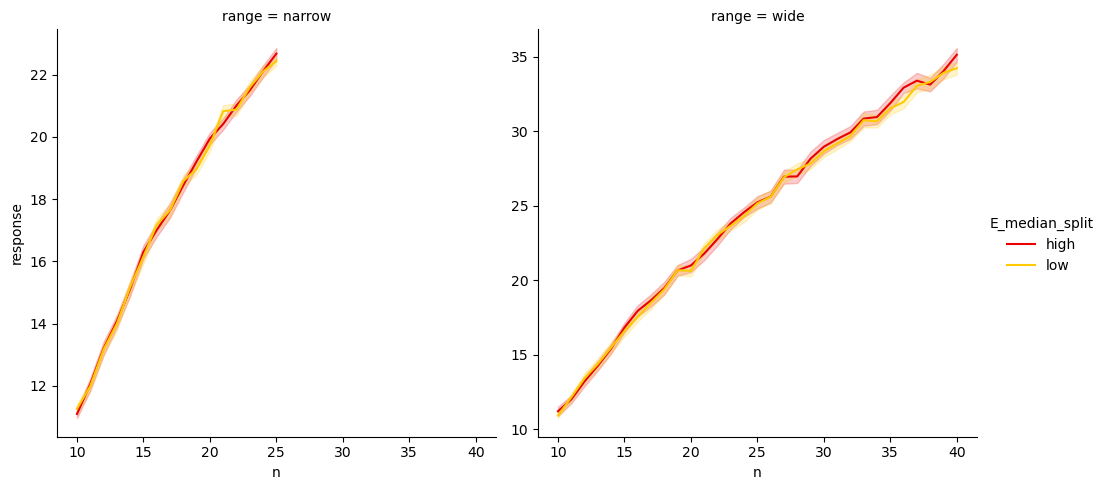

In [ ]:
tmp = df.groupby(['subject', 'n', 'range', 'E_median_split'])[['response']].mean()

sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='response',
    hue='E_median_split',
    col='range',
    kind='line',
    errorbar='se',
    palette='hot',
    facet_kws={'sharey': False, 'sharex': True},
)



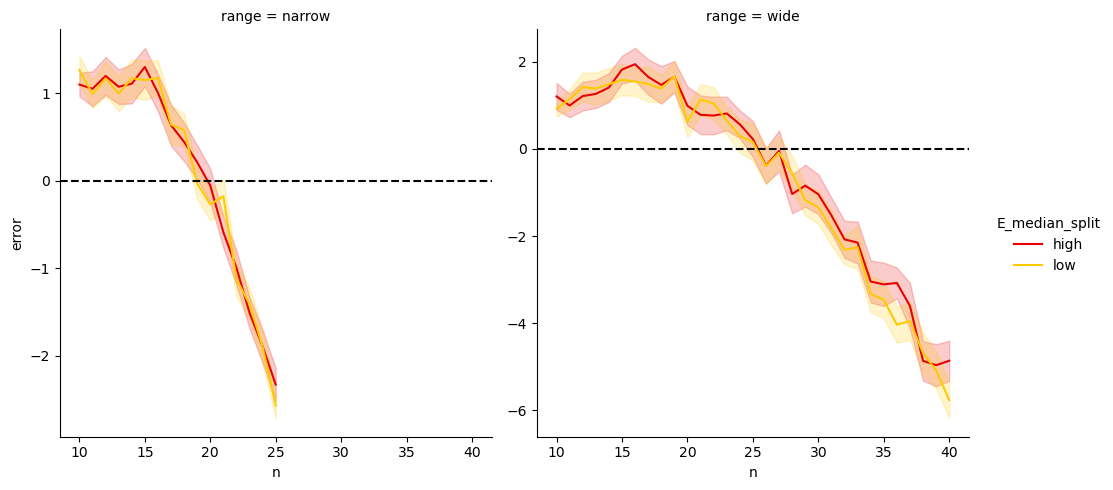

In [80]:
tmp = df.groupby(['subject', 'n', 'range', 'E_median_split'])[['error']].mean()

g = sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='error',
    hue='E_median_split',
    col='range',
    kind='line',
    errorbar='se',
    palette=sns.color_palette('hot', n_colors=2),
    facet_kws={'sharey': False, 'sharex': True},
)

g.map(plt.axhline, y=0, ls='--', c='k')

In [76]:
import pingouin as pg

pg.rm_anova(
    data=df.reset_index(),
    dv='error',
    within=['range', 'E_median_split'],
    subject='subject',
    correction=False,
)

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,range,21.842807,1,38,21.842807,22.137146,0.000033,0.000033,0.085730,1.0
1,E_median_split,0.197364,1,38,0.197364,3.448779,0.071062,0.071062,0.000847,1.0
2,range * E_median_split,0.172331,1,38,0.172331,3.098314,0.086421,0.086421,0.000739,1.0


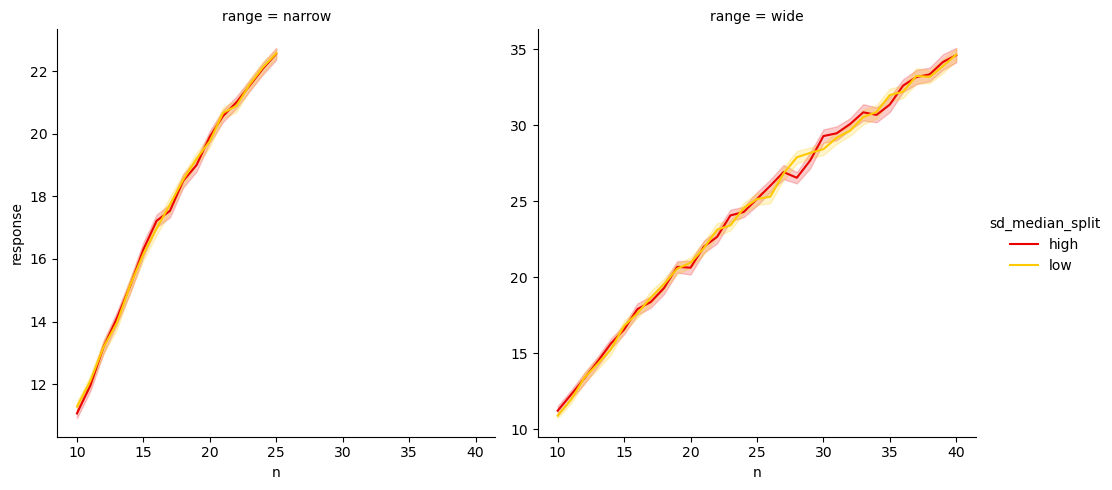

In [64]:
tmp = df.groupby(['subject', 'n', 'range', 'sd_median_split'])[['response']].mean()

sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='response',
    hue='sd_median_split',
    col='range',
    kind='line',
    errorbar='se',
    palette='hot',
    facet_kws={'sharey': False, 'sharex': True},
)

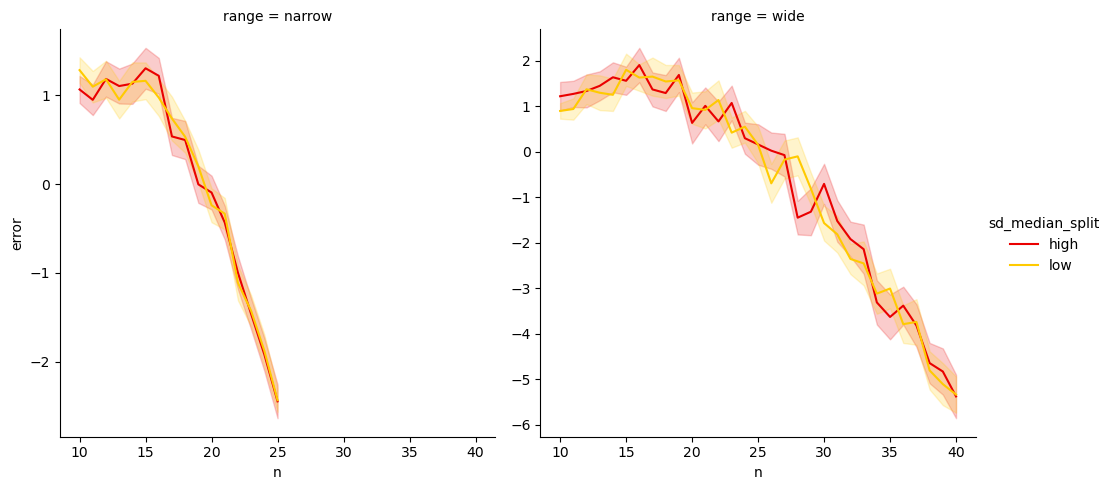

In [65]:
tmp = df.groupby(['subject', 'n', 'range', 'sd_median_split'])[['error']].mean()

sns.relplot(
    data=tmp.reset_index(),
    x='n',
    y='error',
    hue='sd_median_split',
    col='range',
    kind='line',
    errorbar='se',
    palette='hot',
    facet_kws={'sharey': False, 'sharex': True},
)

In [79]:
pg.rm_anova(
    data=df.reset_index(),
    dv='error',
    within=['range', 'sd_median_split'],
    subject='subject',
    correction=False,
)

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,range,21.957048,1,38,21.957048,22.263012,0.000032,0.000032,0.086088,1.0
1,sd_median_split,0.044924,1,38,0.044924,0.760592,0.388620,0.388620,0.000193,1.0
2,range * sd_median_split,0.111834,1,38,0.111834,1.711338,0.198670,0.198670,0.000480,1.0


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60440/3083681648.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = df.groupby(['subject', 'range']).apply(lambda x: pg.corr(x['E'], x['response']))


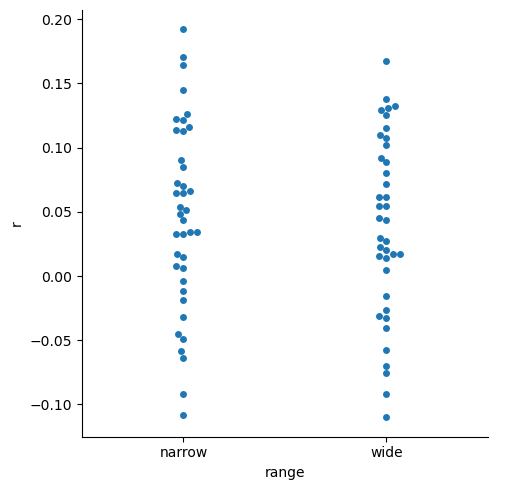

In [90]:
tmp = df.groupby(['subject', 'range']).apply(lambda x: pg.corr(x['E'], x['response']))

sns.catplot(x='range', y='r', data=tmp.reset_index(), kind='swarm')